# ML Practice with Scikit-Learn
### Phases: Preprocessing → Supervised Learning → Evaluation → Clustering → Tuning & Pipelines

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
import joblib

print('All imports successful!')

All imports successful!


---
## EDA — Exploratory Data Analysis
**Always do this before any decision** (which fillna method, which scaler, which model)

### Small vs Large threshold
| | Small | Medium | Large |
|---|---|---|---|
| **Rows** | < 10k | 10k – 1M | > 1M |
| **Columns** | < 20 | 20 – 100 | > 100 |

**Rule:** Never just look at the table. Table = *what*, Graph = *shape and pattern*. You need both.

### Decision flow
```
Load data
   ↓
shape + dtypes + describe()         ← always first (6 lines below)
   ↓
isnull().sum()  →  drop / mean / median / mode
   ↓
histogram + boxplot per column  →  skewed? → median  |  normal? → mean  |  scaler choice
   ↓
value_counts() on target  →  class imbalance? → affects which metric to trust
   ↓
scatter / correlation  →  linear pattern? → Linear Regression
                          no pattern?     → tree-based models
```

In [ ]:
# ── Step 1: Always run these 6 lines first ──────────────────────────────────
import seaborn as sns
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
eda_df = iris.frame          # 150 rows, 4 numeric features + 1 target

print("shape     :", eda_df.shape)
print("\ndtypes:\n",   eda_df.dtypes)
print("\ndescribe:\n", eda_df.describe().round(2))
print("\nmissing:\n",  eda_df.isnull().sum())
print("\ntarget counts:\n", eda_df['target'].value_counts())

In [ ]:
# ── Step 2: Histogram + Boxplot — shape and outliers ────────────────────────
num_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for i, col in enumerate(num_cols):
    eda_df[col].hist(ax=axes[0, i], bins=20, color='steelblue', edgecolor='white')
    axes[0, i].set_title(col, fontsize=8)
    axes[0, i].set_ylabel('Frequency' if i == 0 else '')

    eda_df.boxplot(column=col, ax=axes[1, i])
    axes[1, i].set_title('')

axes[0, 0].set_ylabel('Histogram')
axes[1, 0].set_ylabel('Boxplot')
plt.suptitle('Histogram (top) + Boxplot (bottom) per feature', y=1.01)
plt.tight_layout()
plt.show()

# Skewness score — use median if abs(skew) > 0.5
print("\nSkewness (|value| > 0.5 → use median):")
print(eda_df[num_cols].skew().round(3))

In [ ]:
# ── Step 3: Correlation heatmap — which features are related? ───────────────
plt.figure(figsize=(6, 4))
sns.heatmap(eda_df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Values close to +1 or -1 → strong relationship → good for Linear Regression
# Values near 0 → no linear relationship → tree models may work better

In [ ]:
# ── Step 4: For LARGE datasets — sample before plotting ─────────────────────
# Plotting 1M points is useless (overplotted) and slow.
# Always sample when rows > 50k.

# Simulating a large dataset
large_df = pd.DataFrame({
    'income': np.random.exponential(scale=50000, size=500_000),  # right-skewed
    'age':    np.random.normal(loc=35, scale=10, size=500_000),
})

print("Full dataset shape :", large_df.shape)
print("Skewness:\n", large_df.skew().round(3))

# Sample 5000 rows for plotting
sample_df = large_df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sample_df['income'].hist(bins=40, ax=axes[0], color='salmon')
axes[0].set_title('income — right skewed → use median')
sample_df['age'].hist(bins=40, ax=axes[1], color='steelblue')
axes[1].set_title('age — normal → mean is fine')
plt.tight_layout()
plt.show()

---
## Phase 2 — Data Preprocessing
**Goal:** Handle missing values → Encode categoricals → Scale features → Split data

In [11]:
# Build a messy synthetic dataset
np.random.seed(42)
n = 200

raw_data = pd.DataFrame({
    'age':        np.random.randint(18, 60, n).astype(float),
    'salary':     np.random.randint(30000, 120000, n).astype(float),
    'city':       np.random.choice(['Mumbai', 'Delhi', 'Pune', 'Chennai'], n),
    'dept':       np.random.choice(['IT', 'HR', 'Finance', 'Marketing'], n),
    'experience': np.random.randint(0, 20, n).astype(float),
    'promoted':   np.random.choice([0, 1], n, p=[0.6, 0.4]),
})




# Inject missing values
raw_data.loc[np.random.choice(n, 20, replace=False), 'age']    = np.nan
raw_data.loc[np.random.choice(n, 15, replace=False), 'salary'] = np.nan
raw_data.loc[np.random.choice(n, 10, replace=False), 'city']   = np.nan

print('Shape:', raw_data.shape)
print('\nMissing values:\n', raw_data.isnull().sum())
raw_data.head()

Shape: (200, 6)

Missing values:
 age           20
salary        15
city          10
dept           0
experience     0
promoted       0
dtype: int64


,age,salary,city,dept,experience,promoted
0,56.0,55342.0,Chennai,HR,15.0,0
1,46.0,NaN,Chennai,IT,12.0,0
2,32.0,97863.0,Mumbai,Finance,13.0,0
3,25.0,82083.0,Delhi,Finance,2.0,0
4,38.0,95733.0,NaN,IT,5.0,1


In [12]:
df = raw_data.copy()

# --- 1. Handle missing values (direct assignment — safe in pandas 2.0+) ---
df['age']    = df['age'].fillna(df['age'].median())
df['salary'] = df['salary'].fillna(df['salary'].mean())
df['city']   = df['city'].fillna(df['city'].mode()[0])

print('Missing after fix:', df.isnull().sum().sum())  # must be 0

# --- 2. Encode categoricals ---
le = LabelEncoder()
df['dept_encoded'] = le.fit_transform(df['dept'])
print('dept classes:', dict(enumerate(le.classes_)))

city_dummies = pd.get_dummies(df['city'], prefix='city')
df = pd.concat([df, city_dummies], axis=1)
df.drop(columns=['city', 'dept'], inplace=True)

# --- 3. Feature scaling ---
num_features = ['age', 'salary', 'experience']
scaler = StandardScaler()
df[['age_sc', 'salary_sc', 'exp_sc']] = scaler.fit_transform(df[num_features])

print('\nScaled features (mean≈0, std≈1):')
print(df[['age_sc', 'salary_sc', 'exp_sc']].describe().round(2))

Missing after fix: 0
dept classes: {0: 'Finance', 1: 'HR', 2: 'IT', 3: 'Marketing'}

Scaled features (mean≈0, std≈1):
       age_sc  salary_sc  exp_sc
count  200.00     200.00  200.00
mean    -0.00       0.00   -0.00
std      1.00       1.00    1.00
min     -1.74      -1.70   -1.59
25%     -0.83      -0.87   -0.92
50%      0.12       0.00    0.10
75%      0.81       0.81    0.81
max      1.72       1.83    1.62


In [13]:
# --- 4. Train / Test Split ---
X = df[['age_sc', 'salary_sc', 'exp_sc', 'dept_encoded']].values
y = df['promoted'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'y_train distribution — 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}')
print(f'y_test  distribution — 0: {(y_test==0).sum()}   1: {(y_test==1).sum()}')

Train: 160 | Test: 40
y_train distribution — 0: 102  1: 58
y_test  distribution — 0: 26   1: 14


---
## Phase 3 — Supervised Learning
### Part A: Regression — Predict Salary from Age + Experience

In [14]:
# Regression dataset: predict salary
np.random.seed(0)
age  = np.random.randint(22, 55, 300).astype(float)
exp  = age - 22 + np.random.normal(0, 2, 300)          # experience loosely tied to age
sal  = 25000 + (age * 800) + (exp * 1500) + np.random.normal(0, 5000, 300)

reg_df = pd.DataFrame({'age': age, 'experience': exp, 'salary': sal})

Xr = reg_df[['age', 'experience']].values
yr = reg_df['salary'].values

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(Xr_train, yr_train)
yr_pred = lr.predict(Xr_test)

print('=== Linear Regression Results ===')
print(f'MAE  : {mean_absolute_error(yr_test, yr_pred):,.0f}')
print(f'MSE  : {mean_squared_error(yr_test, yr_pred):,.0f}')
print(f'RMSE : {np.sqrt(mean_squared_error(yr_test, yr_pred)):,.0f}')
print(f'R²   : {r2_score(yr_test, yr_pred):.4f}')
print(f'\nCoefficients: age={lr.coef_[0]:.1f}, experience={lr.coef_[1]:.1f}')
print(f'Intercept   : {lr.intercept_:.1f}')

=== Linear Regression Results ===
MAE  : 3,463
MSE  : 20,345,834
RMSE : 4,511
R²   : 0.9588

Coefficients: age=805.7, experience=1456.7
Intercept   : 25004.2


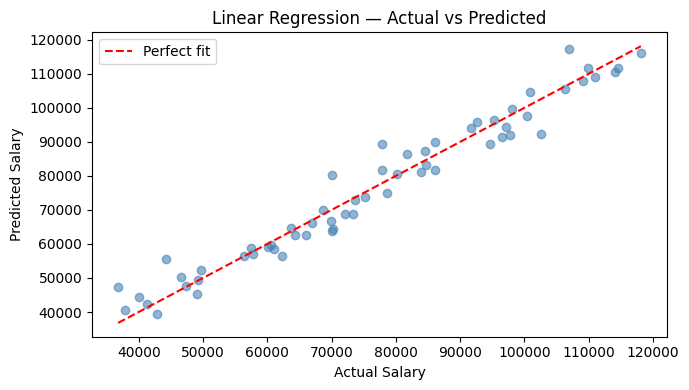

In [15]:
# Visualise: Actual vs Predicted
plt.figure(figsize=(7, 4))
plt.scatter(yr_test, yr_pred, alpha=0.6, color='steelblue')
mn, mx = yr_test.min(), yr_test.max()
plt.plot([mn, mx], [mn, mx], 'r--', label='Perfect fit')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Linear Regression — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### Part B: Classification — Predict Promotion (3 algorithms)

In [17]:
# --- Own dataset for classification: predict student pass/fail ---
np.random.seed(10)
n_students = 300

clf_df = pd.DataFrame({
    'study_hours': np.random.uniform(1, 10, n_students),
    'sleep_hours': np.random.uniform(4, 9, n_students),
    'attendance':  np.random.uniform(50, 100, n_students),
    'prev_score':  np.random.uniform(30, 100, n_students),
})

# Pass if study_hours > 5 and attendance > 70 (with some noise)
noise = np.random.normal(0, 0.5, n_students)
clf_df['pass'] = (
    (clf_df['study_hours'] + noise > 5) & (clf_df['attendance'] > 70)
).astype(int)

print('clf_df shape:', clf_df.shape)
print('Pass / Fail counts:\n', clf_df['pass'].value_counts().to_dict())

# Scale + Split
Xc = StandardScaler().fit_transform(clf_df.drop(columns=['pass']))
yc = clf_df['pass'].values

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)

print(f'\nTrain: {Xc_train.shape[0]} | Test: {Xc_test.shape[0]}')

# --- Compare 4 classifiers ---
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':       DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []
for name, clf in classifiers.items():
    clf.fit(Xc_train, yc_train)
    pred = clf.predict(Xc_test)
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(yc_test, pred),
        'Precision': precision_score(yc_test, pred),
        'Recall':    recall_score(yc_test, pred),
        'F1':        f1_score(yc_test, pred),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('\n', results_df.round(3))

clf_df shape: (300, 5)
Pass / Fail counts:
 {0: 213, 1: 87}

Train: 240 | Test: 60

                      Accuracy  Precision  Recall     F1
Model                                                  
Logistic Regression     0.900      0.923   0.706  0.800
KNN (k=5)               0.917      0.929   0.765  0.839
Decision Tree           0.983      1.000   0.941  0.970
Random Forest           0.983      1.000   0.941  0.970


---
## Phase 4 — Model Evaluation
Deep-dive into the best classifier: Confusion Matrix + Classification Report

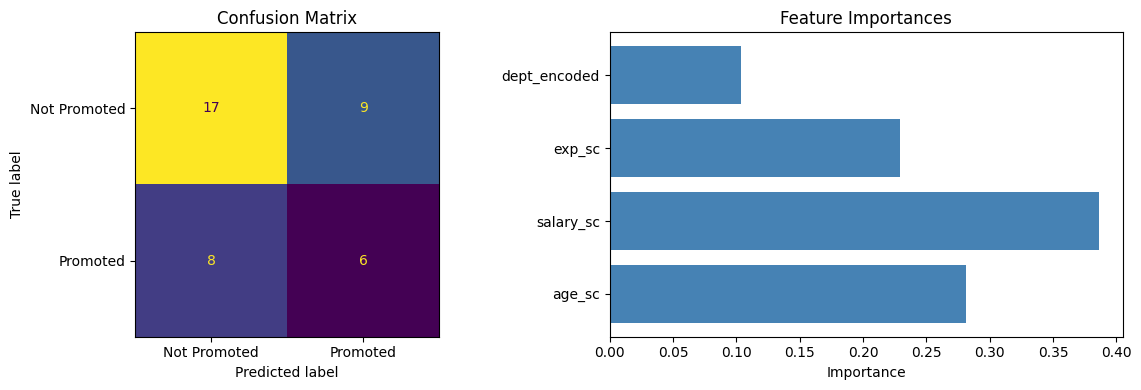


Classification Report:
              precision    recall  f1-score   support

Not Promoted       0.68      0.65      0.67        26
    Promoted       0.40      0.43      0.41        14

    accuracy                           0.57        40
   macro avg       0.54      0.54      0.54        40
weighted avg       0.58      0.57      0.58        40



In [18]:
best_clf = RandomForestClassifier(n_estimators=100, random_state=42)
best_clf.fit(X_train, y_train)
best_pred = best_clf.predict(X_test)

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Promoted', 'Promoted'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

# Feature importances
feat_names = ['age_sc', 'salary_sc', 'exp_sc', 'dept_encoded']
importances = best_clf.feature_importances_
axes[1].barh(feat_names, importances, color='steelblue')
axes[1].set_title('Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, best_pred, target_names=['Not Promoted', 'Promoted']))

In [19]:
# Cross-Validation — more reliable than a single train/test split
cv_scores = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42),
                            X, y, cv=5, scoring='f1')

print('5-Fold Cross-Validation F1 Scores:', cv_scores.round(3))
print(f'Mean: {cv_scores.mean():.3f}  |  Std: {cv_scores.std():.3f}')

5-Fold Cross-Validation F1 Scores: [0.182 0.087 0.2   0.182 0.37 ]
Mean: 0.204  |  Std: 0.092


---
## Phase 5 — Unsupervised Learning
### K-Means Clustering + PCA Visualization

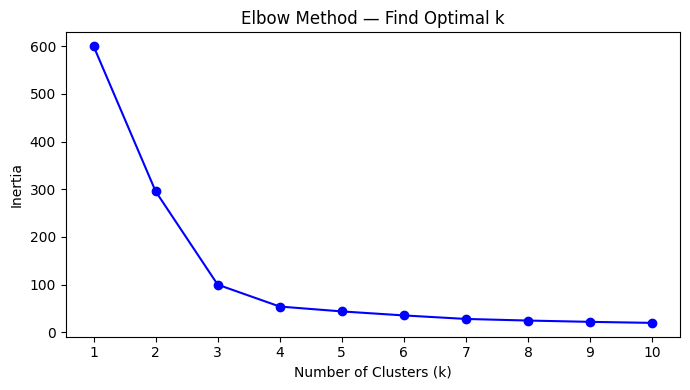

In [23]:
# Synthetic customer dataset (Age vs Spending Score)
np.random.seed(7)
n_customers = 300
age_cust    = np.random.randint(18, 70, n_customers)
spend_score = np.random.randint(1, 100, n_customers)

# Add clear cluster structure
cluster_data = np.vstack([
    np.random.multivariate_normal([25, 80], [[30, 0],[0, 30]], 80),  # Young high-spenders
    np.random.multivariate_normal([55, 75], [[30, 0],[0, 30]], 80),  # Old high-spenders
    np.random.multivariate_normal([40, 25], [[50, 0],[0, 30]], 80),  # Mid-age low-spenders
    np.random.multivariate_normal([25, 20], [[30, 0],[0, 30]], 60),  # Young low-spenders
])


X_clust = StandardScaler().fit_transform(cluster_data)

# Elbow Method
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Find Optimal k')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

Explained variance by 2 components: 100.0%


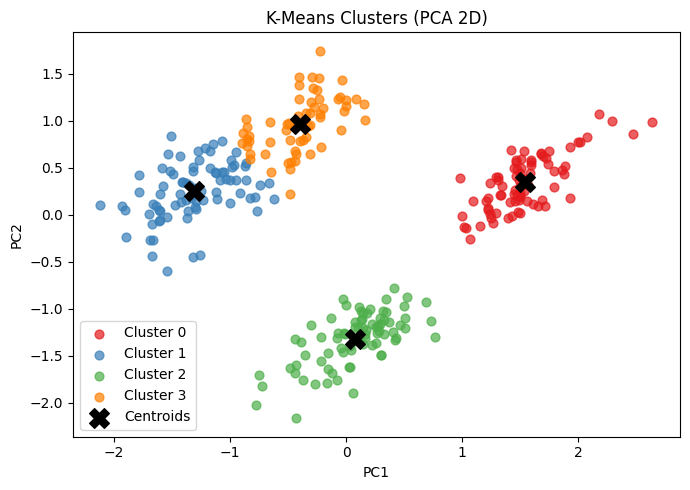


Cluster sizes: {0: 80, 1: 80, 2: 80, 3: 60}


In [24]:
# Fit KMeans with optimal k (looks like 4 from elbow)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_clust)

# PCA to 2D for visualization
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_clust)

print(f'Explained variance by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%')

plt.figure(figsize=(7, 5))
colors = ['#e41a1c','#377eb8','#4daf4a','#ff7f00']
for i in range(4):
    mask = labels == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=colors[i], label=f'Cluster {i}', alpha=0.7, s=40)

centers_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c='black', marker='X', s=200, zorder=5, label='Centroids')
plt.title('K-Means Clusters (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

print('\nCluster sizes:', pd.Series(labels).value_counts().sort_index().to_dict())

---
## Phase 6 — Hyperparameter Tuning & Pipelines

In [27]:
# GridSearchCV — find best params for Decision Tree
param_grid = {
    'max_depth':        [2, 4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'criterion':        ['gini', 'entropy'],
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print('Best params :', grid.best_params_)
print('Best CV F1  :', round(grid.best_score_, 4))

# Evaluate best estimator on test set
tuned_pred = grid.best_estimator_.predict(X_test)
print('Test Accuracy:', accuracy_score(y_test, tuned_pred))
print('Test F1      :', f1_score(y_test, tuned_pred))

Best params : {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Best CV F1  : 0.3484
Test Accuracy: 0.475
Test F1      : 0.3225806451612903


In [29]:
# Pipeline — chain preprocessing + model into one object
# Use raw (unscaled) features to show Pipeline handles scaling internally
X_raw = df[['age', 'salary', 'experience', 'dept_encoded']].values
y_raw = df['promoted'].values

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe.fit(Xp_train, yp_train)
pipe_pred = pipe.predict(Xp_test)

print('Pipeline steps:', [s[0] for s in pipe.steps])
print('Pipeline Accuracy:', accuracy_score(yp_test, pipe_pred))
print('Pipeline F1      :', f1_score(yp_test, pipe_pred))

Pipeline steps: ['scaler', 'clf']
Pipeline Accuracy: 0.575
Pipeline F1      : 0.41379310344827586


In [31]:
# Save & Reload model with joblib
joblib.dump(pipe, 'trained_pipeline.pkl')
print('Model saved to trained_pipeline.pkl')

loaded_pipe = joblib.load('trained_pipeline.pkl')
reload_pred = loaded_pipe.predict(Xp_test)

print('Reloaded model accuracy:', accuracy_score(yp_test, reload_pred))
print('Predictions match original:', np.array_equal(pipe_pred, reload_pred))

# Predict on a single new employee
new_employee = np.array([[35, 75000, 10, 2]])  # age, salary, experience, dept_encoded
prediction   = loaded_pipe.predict(new_employee)
proba        = loaded_pipe.predict_proba(new_employee)
print(f'\nNew employee prediction: {"Promoted" if prediction[0]==1 else "Not Promoted"}')
print(f'Probability — Not Promoted: {proba[0][0]:.2f} | Promoted: {proba[0][1]:.2f}')

Model saved to trained_pipeline.pkl
Reloaded model accuracy: 0.575
Predictions match original: True

New employee prediction: Not Promoted
Probability — Not Promoted: 0.59 | Promoted: 0.41


---
## Summary Cheatsheet

| Task | Key Class/Function |
|---|---|
| Fill missing values | `df.fillna(median/mean/mode)` |
| Label encode | `LabelEncoder().fit_transform()` |
| One-Hot encode | `pd.get_dummies()` |
| Scale features | `StandardScaler()` / `MinMaxScaler()` |
| Split data | `train_test_split(X, y, test_size=0.2, stratify=y)` |
| Linear Regression | `LinearRegression()` → MAE / RMSE / R² |
| Classification | `LogisticRegression` / `KNN` / `DecisionTree` / `RandomForest` |
| Evaluate classifier | `accuracy_score`, `f1_score`, `classification_report` |
| Cross-validate | `cross_val_score(clf, X, y, cv=5)` |
| Cluster | `KMeans(n_clusters=k).fit_predict(X)` |
| Reduce dims | `PCA(n_components=2).fit_transform(X)` |
| Tune params | `GridSearchCV(clf, param_grid, cv=5)` |
| Chain steps | `Pipeline([('scaler', ...), ('clf', ...)])` |
| Save model | `joblib.dump(model, 'file.pkl')` |
| Load model | `joblib.load('file.pkl')` |